In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import os

os.environ["PYSPARK_SUBMIT_ARGS"] = (
    "--driver-class-path /Users/sydneysailors/smart-store-sydney/lib/sqlite-jdbc-3.51.0.0.jar "
    "--jars /Users/sydneysailors/smart-store-sydney/lib/sqlite-jdbc-3.51.0.0.jar "
    "pyspark-shell"
)

In [3]:
from pyspark.sql import SparkSession

dw_path = "/Users/sydneysailors/smart-store-sydney/data/dw/smart_sales.db"

spark = SparkSession.builder.appName("SmartStoreOLAP").getOrCreate()

# Test driver
spark._jvm.java.lang.Class.forName("org.sqlite.JDBC")

25/11/30 13:52:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


JavaObject id=o31

In [4]:
#Load sales
sales_df = (
    spark.read.format("jdbc")
    .options(url=f"jdbc:sqlite:{dw_path}", dbtable="sales", driver="org.sqlite.JDBC")
    .load()
)

#Load customers
customers_df = (
    spark.read.format("jdbc")
    .options(url=f"jdbc:sqlite:{dw_path}", dbtable="customers", driver="org.sqlite.JDBC")
    .load()
)

#Load products
products_df = (
    spark.read.format("jdbc")
    .options(url=f"jdbc:sqlite:{dw_path}", dbtable="products", driver="org.sqlite.JDBC")
    .load()
)

sales_df.show(5)
customers_df.show(5)
products_df.show(5)


+-------+---------+-----------+----------+--------+-----------+------------+---------------+-----+
|sale_id|sale_date|customer_id|product_id|store_id|campaign_id|sales_amount|discount_amount|state|
+-------+---------+-----------+----------+--------+-----------+------------+---------------+-----+
|      1|   5/4/25|       1034|      2059|     402|        0.0|      2048.2|          12.45|   CA|
|      2|   5/4/25|       1066|      2048|     403|        1.0|      321.87|            7.8|   NY|
|      3|   5/4/25|       1116|      2041|     403|        3.0|     3216.84|           25.0|   TX|
|      4|   5/4/25|       1071|      2096|     404|        2.0|     1613.23|           18.3|   FL|
|      5|   5/4/25|       1020|      2060|     401|        0.0|      408.38|            5.5|   IL|
+-------+---------+-----------+----------+--------+-----------+------------+---------------+-----+
only showing top 5 rows
+-----------+-------------+-------+---------+---+-------------------+
|customer_id|  

In [5]:
sales_df.createOrReplaceTempView("sale")
customers_df.createOrReplaceTempView("customer")
products_df.createOrReplaceTempView("product")

In [6]:
slice_df = spark.sql("""
    SELECT *
    FROM product
    WHERE category = 'Electronics'
""")
slice_df.show(10)

+----------+-------------------+-----------+----------+----------------+-------------------+
|product_id|       product_name|   category|unit_price|manufacture_year|availability_status|
+----------+-------------------+-----------+----------+----------------+-------------------+
|      2000|     Electronics-Be|Electronics|     969.0|            2021|           In stock|
|      2007|      Clothing-Over|Electronics|     583.0|            2003|           In stock|
|      2012|    Clothing-Artist|Electronics|     623.0|            2023|       Out of stock|
|      2017|Electronics-Feeling|Electronics|     464.0|            2022|           In stock|
|      2022|       Home-Economy|Electronics|     671.0|            2017|           In stock|
|      2023|          Home-Yeah|Electronics|     940.0|            2016|       Discontinued|
|      2028|   Electronics-Take|Electronics|     638.0|            2010|       Out of stock|
|      2029|      Home-Yourself|Electronics|      14.0|            202

In [34]:
dice_df = spark.sql("""
    SELECT
        c.region AS region,
        c.subscription_status AS subscription_status,
        s.state AS state,
        SUM(s.sales_amount) AS total_revenue
    FROM sale s
    JOIN customer c
        ON s.customer_id = c.customer_id
    GROUP BY
        c.region,
        c.subscription_status,
        s.state
    ORDER BY
        c. region, c. subscription_status
""").toPandas()
print(dice_df.head(20))


     region subscription_status state  total_revenue
0   Central              Active    MI         311.73
1   Central              Active    OK        1549.89
2   Central              Active    VA        1472.37
3   Central              Active    NY        2562.12
4   Central              Active    MN         839.55
5   Central              Active    NJ         383.43
6   Central              Active    MO        1710.97
7   Central              Active    AZ         488.12
8   Central              Active    NM         493.35
9   Central              Active    WY        3072.64
10  Central              Active    AL         976.44
11  Central              Active    WV        2741.72
12  Central              Active    OH        2453.95
13  Central              Active    RI         142.01
14  Central              Active    UT        2000.25
15  Central              Active    IL         646.32
16  Central              Active    SD        1378.56
17  Central              Active    MS        1

In [19]:
drilldown_df = spark.sql("""
    SELECT
        p.category,
        SUM(s.sales_amount) AS total_revenue
    FROM sale s
    JOIN product p
        ON s.product_id = p.product_id
    GROUP BY p.category
    ORDER BY total_revenue DESC
""")

drilldown_df.show()


+-----------+-----------------+
|   category|    total_revenue|
+-----------+-----------------+
|       Home|560926.3000000003|
|   Clothing|472768.3499999993|
|Electronics|461414.4399999997|
|     Office|460254.6099999997|
+-----------+-----------------+



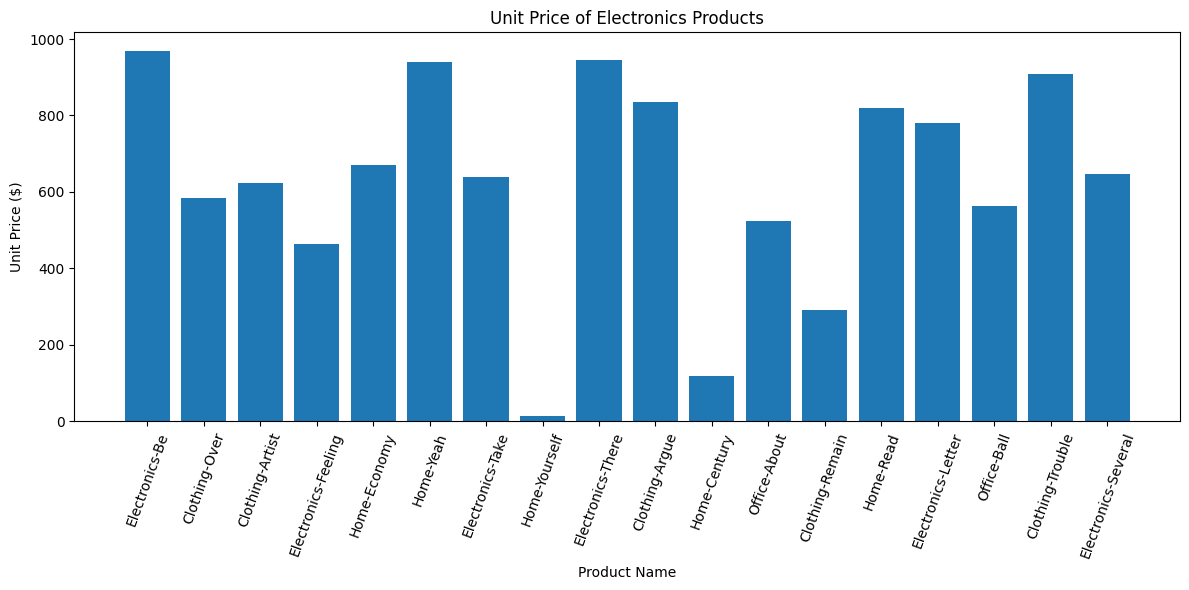

In [16]:
# Convert Spark DF to Pandas
slice_pdf = slice_df.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(slice_pdf['product_name'], slice_pdf['unit_price'])
plt.xlabel("Product Name")
plt.ylabel("Unit Price ($)")
plt.title("Unit Price of Electronics Products")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()


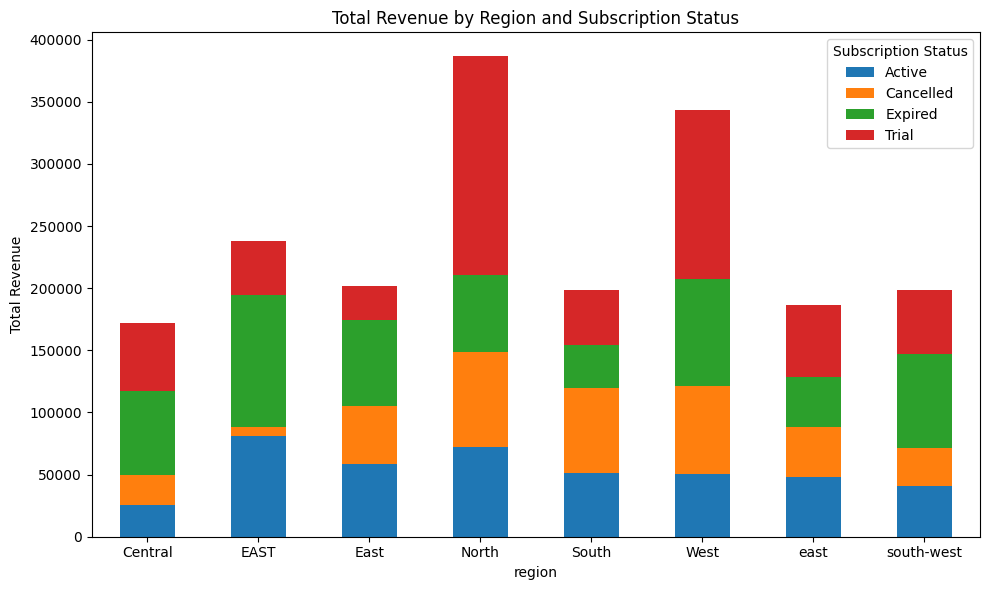

In [37]:
import matplotlib.pyplot as plt

# Pivot the data: regions as rows, subscription_status as columns
pivot = dice_df.pivot_table(
    index='region',
    columns='subscription_status',
    values='total_revenue',
    aggfunc='sum',
    fill_value=0
)

# Plot stacked bar chart
pivot.plot(kind='bar', stacked=True, figsize=(10,6))
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Region and Subscription Status")
plt.xticks(rotation=0)
plt.legend(title="Subscription Status")
plt.tight_layout()
plt.show()


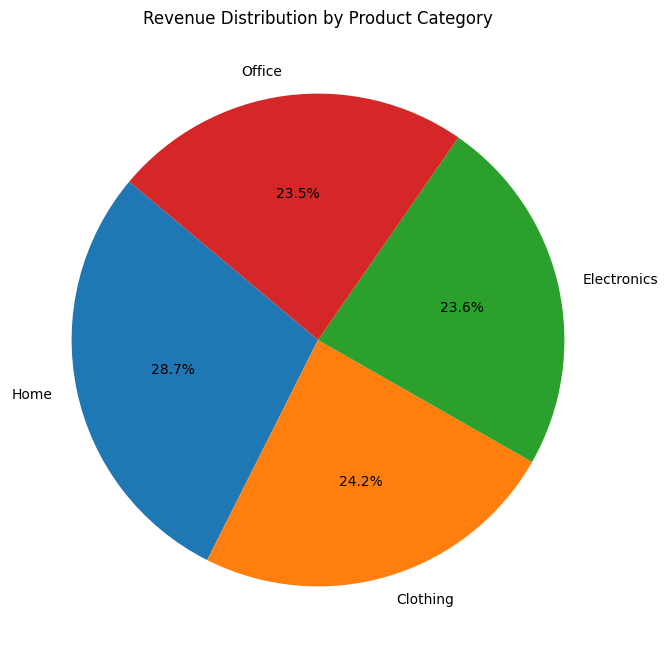

In [ ]:
import matplotlib.pyplot as plt

# Use the Pandas DataFrame
plt.figure(figsize=(8,8))
plt.pie(
    drilldown_pdf['total_revenue'],
    labels=drilldown_pdf['category'],
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Revenue Distribution by Product Category")
plt.show()
